<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Percent_Older_Adults_(65%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

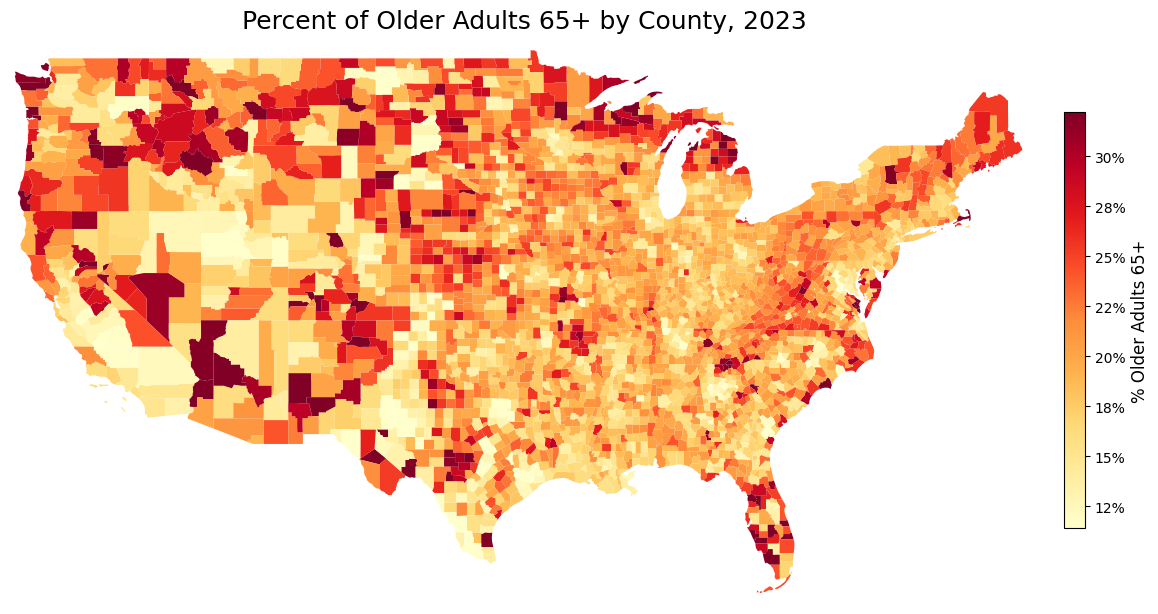

In [1]:
# Link to download: https://data.census.gov/table/ACSDP5Y2023.DP05?q=population&g=010XX00US,$0500000

# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read Excel file
file = "/content/ACSDP5Y2023.DP05-2026-06-18T144252.xlsx"

acs_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Find the row for "65 years and over"
older_row = acs_data[acs_data[0] == "65 years and over"].index[0]

# Every county starts at column 5, then repeats every 4 columns:
# Estimate, Margin of Error, Percent, Percent Margin of Error
county_columns = list(range(5, acs_data.shape[1], 4))

older_data = []

for col in county_columns:
    county_name = acs_data.iloc[0, col]
    percent_older = acs_data.iloc[older_row, col + 2]

    older_data.append({
        "county_state": county_name,
        "percent_older_adults": percent_older
    })

older_df = pd.DataFrame(older_data)

# Remove missing county names
older_df = older_df[older_df["county_state"].notna()].copy()

# Remove Puerto Rico if only mapping the U.S. lower 48
older_df = older_df[
    ~older_df["county_state"].str.contains("Puerto Rico", na=False)
].copy()

# Clean percent column
older_df["percent_older_adults"] = (
    older_df["percent_older_adults"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

older_df["percent_older_adults"] = pd.to_numeric(
    older_df["percent_older_adults"],
    errors="coerce"
)

# Split county and state from names like "Autauga County, Alabama"
older_df[["county", "state"]] = older_df["county_state"].str.rsplit(
    ", ",
    n=1,
    expand=True
)

# Read county shapefile
county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Merge county boundaries with older adults data
# Use NAMELSAD because it includes "County"
merged = counties.merge(
    older_df,
    left_on=["NAMELSAD", "STATE_NAME"],
    right_on=["county", "state"],
    how="left"
)

# Remove Alaska, Hawaii, Puerto Rico, and territories
lower48 = merged[
    ~merged["STUSPS"].isin(["AK", "HI", "PR", "GU", "VI", "MP", "AS"])
].copy()

# Remove missing values
lower48 = lower48[lower48["percent_older_adults"].notna()].copy()

# Make colors look better
vmin = lower48["percent_older_adults"].quantile(0.02)
vmax = lower48["percent_older_adults"].quantile(0.98)

# Make map
fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="percent_older_adults",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "% Older Adults 65+",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    }
)

# Make colorbar show percent signs
cbar = ax.get_figure().axes[-1]

cbar.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

cbar.set_ylabel("% Older Adults 65+", fontsize=12)

ax.set_title("Percent of Older Adults 65+ by County, 2023", fontsize=18)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")

plt.show()